In [1]:
import os
import gymnasium as gym
import pandas as pd
from skopt.space import Real
from multiprocessing import Pool
from tqdm import tqdm


from popy.simulation_tools import *
from popy.io_tools import load_behavior, load_behavior_yuri
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import *
from popy.config import PROJECT_PATH_LOCAL

from popy.simulation_helpers import fit_simulate, simulate_agent
from popy.plotting.plotting_tools import show_target_selection, show_target_selection_compact

MODELS = {
    "Repeating agent": {
        "agent_class": RepeatingAgent,
        "fixed_params": {},
        "free_params": ["epsilon"],
    },

    "WSLS": {
        "agent_class": WSLSAgent,
        "fixed_params": {},
        "free_params": ["epsilon"],
    },

    "Standard RL": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": False},
        "free_params": ["alpha", "beta"],
    },
    "Standard RL - stickiness": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": False},
        "free_params": ["alpha", "beta", "stickiness_bias"],
    },
    "Standard RL - forgetting": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": False},
        "free_params": ["alpha", "beta", "forgetting_rate", "forgetting_threshold"],
    },
    "Standard RL - stickiness + forgetting": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": False},
        "free_params": ["alpha", "beta", "forgetting_rate", "forgetting_threshold", "stickiness_bias"],
    },

    "Inferential RL": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": True},
        "free_params": ["alpha", "beta"],
    },
    "Inferential RL - stickiness": {    
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": True},
        "free_params": ["alpha", "beta", "stickiness_bias"],
    },
    "Inferential RL - stickiness + spatial bias": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": True},
        "free_params": ["alpha", "beta", "stickiness_bias", "b2_bias"],
    },
    "Inferential RL - stickiness + multiple alphas": {
        "agent_class": QLearner,
        "fixed_params": {"structure_aware": True},
        "free_params": ["alpha", "alpha_unchosen", "beta", "stickiness_bias"],
    },

    "Foraging - no reset": {
        "agent_class": ForagingAgent,
        "fixed_params": {"reset_on_switch": False},
        "free_params": ["alpha", "beta", "V0"],
    },
    "Foraging": {
        "agent_class": ForagingAgent,
        "fixed_params": {"reset_on_switch": True},
        "free_params": ["alpha", "beta", "V0"],
    },
    "Foraging - abandoned bias": {
        "agent_class": ForagingAgent,
        "fixed_params": {"reset_on_switch": True},
        "free_params": ["alpha", "beta",  "V0", "abandoned_bias", "abandoned_decay"],
    },
    "Foraging - abandoned bias + spatial bias": {
        "agent_class": ForagingAgent,
        "fixed_params": {"reset_on_switch": True},
        "free_params": ["alpha", "beta",  "V0", "abandoned_bias", "abandoned_decay", "b2_bias"],
    },
    "Foraging - adaptive threshold": {
        "agent_class": ForagingAgentAdaptive,
        "fixed_params": {'alpha_threshold': 0.05},
        "free_params": [],
    },
    "HMMAgent": {
        "agent_class": HMMAgent,
        "fixed_params": {},
    },
    "HSMMAgent": {
        "agent_class": HSMMAgent,
        "fixed_params": {},
    },
}

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-qmudezr2 because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
behavs = []
for model_name in ['HSMMAgent', 'HMMAgent']:

    env = gym.make(
        "zsombi/monkey-bandit-task-v0", 
        n_arms=3, 
        max_episode_steps=10_000,
    )

    """Optimize a single model and return results."""
    model_params = MODELS[model_name]

    agent_class = model_params["agent_class"]
    fixed_params = model_params["fixed_params"]
    params = {}

    # Simulate behavior with best parameters
    behav = simulate_agent(
        agent_class=agent_class, 
        params=params,
        env=env, 
        fixed_params=fixed_params, 
        behavioral_variables=[],
        verbose=False
    )
    reward_rate = behav['reward'].mean()
    proba_best = (behav['action'] == behav['best_arm']).mean()

    print("Model", model_name)
    print(f"Simulated behavior with model: {model_name}")
    print(f"Reward rate: {reward_rate:.3f}")
    print(f"Proba. choosing best target: {proba_best:.3f}")

    # keep only models in agents_to_show.keys() and renaming them
    behav['model'] = model_name

    # Apply the function to create the monkey column
    behav['monkey'] = behav['model']
    behav['session'] = 0
    behavs.append(behav)

# Concatenate all behaviors into a single DataFrame
behavs_df = pd.concat(behavs, ignore_index=True)
behavs_df

Model HSMMAgent
Simulated behavior with model: HSMMAgent
Reward rate: 0.642
Proba. choosing best target: 0.896
Model HMMAgent
Simulated behavior with model: HMMAgent
Reward rate: 0.582
Proba. choosing best target: 0.810


,trial_id,block_id,best_arm,action,reward,model,monkey,session
0,0,0,2,2,1.0,HSMMAgent,HSMMAgent,0
1,1,0,2,2,1.0,HSMMAgent,HSMMAgent,0
2,2,0,2,2,1.0,HSMMAgent,HSMMAgent,0
3,3,0,2,2,1.0,HSMMAgent,HSMMAgent,0
4,4,0,2,2,1.0,HSMMAgent,HSMMAgent,0
...,...,...,...,...,...,...,...,...
19995,9995,247,1,1,0.0,HMMAgent,HMMAgent,0
19996,9996,247,1,1,1.0,HMMAgent,HMMAgent,0
19997,9997,247,1,1,1.0,HMMAgent,HMMAgent,0
19998,9998,247,1,1,0.0,HMMAgent,HMMAgent,0


HMMAgent HMMAgent - Best target selection: 0.81 ± 0.000000
HSMMAgent HSMMAgent - Best target selection: 0.90 ± 0.000000


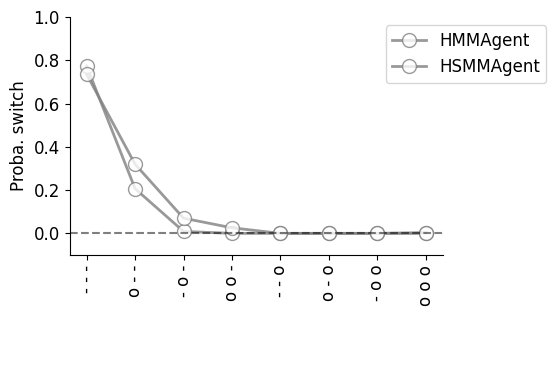

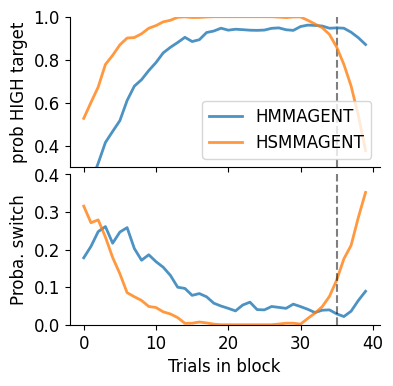

In [3]:
behavs_df = convert_column_format(behavs_df, original='simulation')

behavs_df = add_history_of_feedback(behavs_df, num_trials=3, one_column=False, coding=(0, 1))
behavs_df = add_switch_info(behavs_df, add_trials_since_switch=True, flip_coding=False)
behavs_df = behavs_df.dropna()

fig1, _ = plot_hist_thingy(behavs_df, paper_format=False)
# remove legend
plt.legend([], [], frameon=False)
fig2, _ = plot_strategy(behavs_df, paper_format=False, h=2, w=1.6, ylim=[0, .4], verbose=True)
# remove legend
plt.legend([], [], frameon=False)
